Exercice 1 : Détection et suppression des doublons


In [ ]:
import pandas as pd

### Charger l'ensemble de données Titanic
Nous allons charger le fichier `train.csv` comme l'ensemble de données principal du Titanic.

In [ ]:
df_titanic = pd.read_csv('/content/train.csv')
print(f"Forme de l'ensemble de données avant la suppression des doublons: {df_titanic.shape}")

Forme de l'ensemble de données avant la suppression des doublons: (891, 12)


### Identifier les lignes en double
Nous allons identifier les lignes en double en nous basant sur toutes les colonnes.

In [ ]:
duplicate_rows = df_titanic[df_titanic.duplicated()]
print(f"Nombre de lignes en double détectées: {len(duplicate_rows)}")

Nombre de lignes en double détectées: 0


### Supprimer les lignes en double
Nous allons maintenant supprimer ces lignes en double de l'ensemble de données.

In [ ]:
df_titanic_cleaned = df_titanic.drop_duplicates()
print(f"Forme de l'ensemble de données après la suppression des doublons: {df_titanic_cleaned.shape}")

Forme de l'ensemble de données après la suppression des doublons: (891, 12)


### Vérification de la suppression des doublons
Nous comparons le nombre de lignes avant et après la suppression pour confirmer l'opération.

In [ ]:
initial_rows = df_titanic.shape[0]
cleaned_rows = df_titanic_cleaned.shape[0]

print(f"Nombre de lignes avant la suppression: {initial_rows}")
print(f"Nombre de lignes après la suppression: {cleaned_rows}")
print(f"Nombre de doublons supprimés: {initial_rows - cleaned_rows}")

Nombre de lignes avant la suppression: 891
Nombre de lignes après la suppression: 891
Nombre de doublons supprimés: 0


🌟 Exercice 2 : Gestion des valeurs manquantes


### Identifier les colonnes comportant des valeurs manquantes
Nous allons commencer par identifier les colonnes qui contiennent des valeurs manquantes et calculer le pourcentage de ces valeurs.

In [ ]:
missing_values = df_titanic_cleaned.isnull().sum()
missing_percentage = (df_titanic_cleaned.isnull().sum() / len(df_titanic_cleaned)) * 100

missing_info = pd.DataFrame({
    'Nombre de valeurs manquantes': missing_values,
    '% de valeurs manquantes': missing_percentage
})

# Filtrer uniquement les colonnes avec des valeurs manquantes
missing_info = missing_info[missing_info['Nombre de valeurs manquantes'] > 0].sort_values(by='% de valeurs manquantes', ascending=False)

display(missing_info)

,Nombre de valeurs manquantes,% de valeurs manquantes
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


#### Gestion de la colonne
Imputation par le mode.

In [ ]:
mode_embarked = df_titanic_cleaned['Embarked'].mode()[0]
df_titanic_cleaned['Embarked'].fillna(mode_embarked, inplace=True)
print(f"Valeurs manquantes dans 'Embarked' après imputation: {df_titanic_cleaned['Embarked'].isnull().sum()}")

Valeurs manquantes dans 'Embarked' après imputation: 0


#### Gestion de la colonne `Age`
Imputation par la médiane.

In [ ]:
median_age = df_titanic_cleaned['Age'].median()
df_titanic_cleaned['Age'].fillna(median_age, inplace=True)
print(f"Valeurs manquantes dans 'Age' après imputation: {df_titanic_cleaned['Age'].isnull().sum()}")

Valeurs manquantes dans 'Age' après imputation: 0


/tmp/ipykernel_5468/172278580.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titanic_cleaned['Age'].fillna(median_age, inplace=True)


#### Gestion de la colonne `Cabin`
Remplacer les valeurs manquantes par 'Unknown'.

In [ ]:
df_titanic_cleaned['Cabin'].fillna('Unknown', inplace=True)
print(f"Valeurs manquantes dans 'Cabin' après remplacement: {df_titanic_cleaned['Cabin'].isnull().sum()}")

Valeurs manquantes dans 'Cabin' après remplacement: 0


/tmp/ipykernel_5468/1707399856.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titanic_cleaned['Cabin'].fillna('Unknown', inplace=True)


### Vérification finale des valeurs manquantes
Nous allons vérifier l'état de l'ensemble de données après toutes les opérations de gestion des valeurs manquantes.

In [ ]:
final_missing_values = df_titanic_cleaned.isnull().sum()
final_missing_percentage = (df_titanic_cleaned.isnull().sum() / len(df_titanic_cleaned)) * 100

final_missing_info = pd.DataFrame({
    'Nombre de valeurs manquantes': final_missing_values,
    '% de valeurs manquantes': final_missing_percentage
})

display(final_missing_info[final_missing_info['Nombre de valeurs manquantes'] > 0])

if final_missing_info['Nombre de valeurs manquantes'].sum() == 0:
    print("Toutes les valeurs manquantes ont été traitées.")
else:
    print("Il reste des valeurs manquantes dans l'ensemble de données.")

,Nombre de valeurs manquantes,% de valeurs manquantes


Toutes les valeurs manquantes ont été traitées.


Exercice 3 : Ingénierie des fonctionnalités


### Création de la fonctionnalité `Family Size`
Nous allons créer une nouvelle fonctionnalité appelée `FamilySize` en combinant `SibSp` (nombre de frères et sœurs/conjoints à bord) et `Parch` (nombre de parents/enfants à bord), plus 1 pour le passager lui-même.

In [ ]:
df_titanic_cleaned['FamilySize'] = df_titanic_cleaned['SibSp'] + df_titanic_cleaned['Parch'] + 1
display(df_titanic_cleaned[['SibSp', 'Parch', 'FamilySize']].head())

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


### Extraction et nettoyage de la fonctionnalité `Title`
Nous allons extraire le titre de la colonne `Name` en utilisant des expressions régulières, puis regrouper les titres rares pour simplifier.

In [ ]:
df_titanic_cleaned['Title'] = df_titanic_cleaned['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Regrouper les titres rares
df_titanic_cleaned['Title'] = df_titanic_cleaned['Title'].replace(['Lady', 'Countess','Capt', 'Col', \
                                                 'Don', 'Dr', 'Major', 'Rev', 'Sir', \
                                                 'Jonkheer', 'Dona', 'Mlle', 'Ms', 'Mme'],
                                                'Rare/Other')

# Simplifier les titres Mlle, Ms, Mme
df_titanic_cleaned['Title'] = df_titanic_cleaned['Title'].replace({'Mlle': 'Rare/Other', 'Ms': 'Rare/Other', 'Mme': 'Rare/Other'})

print("Distribution des titres après nettoyage:")
display(df_titanic_cleaned['Title'].value_counts())

Distribution des titres après nettoyage:


<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_5468/23708811.py:1: SyntaxWarning: invalid escape sequence '\.'
  df_titanic_cleaned['Title'] = df_titanic_cleaned['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Rare/Other,27


### Conversion des variables catégorielles en format numérique
Nous allons utiliser l'encodage par étiquette pour 'Sex' et 'Embarked', et l'encodage One-Hot pour la nouvelle fonctionnalité 'Title'.

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Encodage par étiquette pour 'Sex'
le = LabelEncoder()
df_titanic_cleaned['Sex_Encoded'] = le.fit_transform(df_titanic_cleaned['Sex'])
print("Mapping 'Sex' vers 'Sex_Encoded':", dict(zip(le.classes_, le.transform(le.classes_))))

# Encodage par étiquette pour 'Embarked' (les valeurs sont déjà nettoyées)
df_titanic_cleaned['Embarked_Encoded'] = le.fit_transform(df_titanic_cleaned['Embarked'])
print("Mapping 'Embarked' vers 'Embarked_Encoded':", dict(zip(le.classes_, le.transform(le.classes_))))

# Encodage One-Hot pour 'Title'
# Créons un DataFrame pour les titres encodés en one-hot
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
title_one_hot = ohe.fit_transform(df_titanic_cleaned[['Title']])
title_df = pd.DataFrame(title_one_hot, columns=ohe.get_feature_names_out(['Title']))

# Réinitialiser l'index du DataFrame principal avant de le joindre
df_titanic_cleaned = df_titanic_cleaned.reset_index(drop=True)

# Joindre le DataFrame encodé en one-hot au DataFrame principal
df_titanic_cleaned = pd.concat([df_titanic_cleaned, title_df], axis=1)

print("Quelques lignes du DataFrame avec les nouvelles colonnes encodées:")
display(df_titanic_cleaned[['Sex', 'Sex_Encoded', 'Embarked', 'Embarked_Encoded', 'Title', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare/Other']].head())

Mapping 'Sex' vers 'Sex_Encoded': {'female': np.int64(0), 'male': np.int64(1)}
Mapping 'Embarked' vers 'Embarked_Encoded': {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}
Quelques lignes du DataFrame avec les nouvelles colonnes encodées:


,Sex,Sex_Encoded,Embarked,Embarked_Encoded,Title,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare/Other
0,male,1,S,2,Mr,0.0,0.0,1.0,0.0,0.0
1,female,0,C,0,Mrs,0.0,0.0,0.0,1.0,0.0
2,female,0,S,2,Miss,0.0,1.0,0.0,0.0,0.0
3,female,0,S,2,Mrs,0.0,0.0,0.0,1.0,0.0
4,male,1,S,2,Mr,0.0,0.0,1.0,0.0,0.0


### Récapitulatif des nouvelles fonctionnalités et encodages
Les colonnes `FamilySize`, `Title`, `Sex_Encoded`, `Embarked_Encoded`, et les colonnes `Title_*` (encodage one-hot) ont été ajoutées ou transformées.

In [ ]:
print("Colonnes du DataFrame après ingénierie des fonctionnalités:")
print(df_titanic_cleaned.columns)
print("Forme du DataFrame après ingénierie des fonctionnalités:", df_titanic_cleaned.shape)

Colonnes du DataFrame après ingénierie des fonctionnalités:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'Title',
       'Sex_Encoded', 'Embarked_Encoded', 'Title_Master', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare/Other'],
      dtype='object')
Forme du DataFrame après ingénierie des fonctionnalités: (891, 21)


Exercice 4 : Détection et traitement des valeurs aberrantes


### Visualisation des distributions pour identifier les valeurs aberrantes
Nous allons utiliser des diagrammes en boîte (box plots) pour visualiser la distribution des colonnes numériques clés (`Age` et `Fare`) et ainsi identifier les valeurs aberrantes.

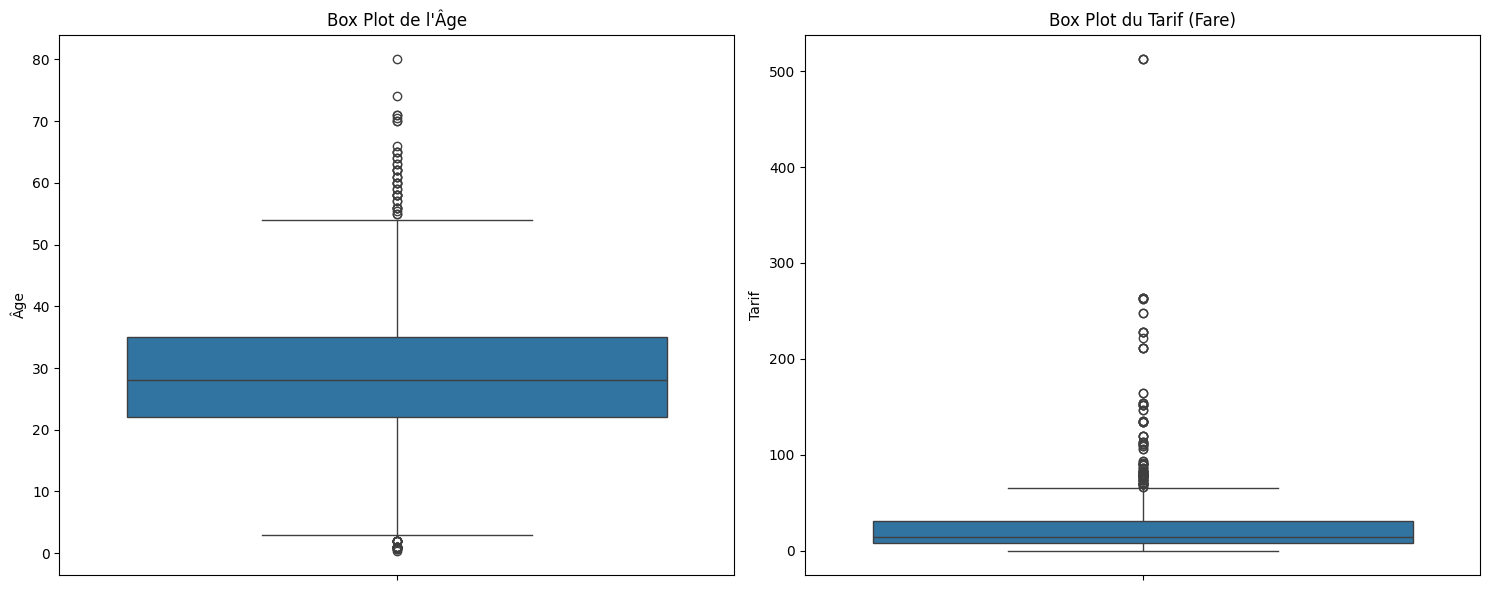

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_titanic_cleaned['Age'])
plt.title('Box Plot de l\'Âge')
plt.ylabel('Âge')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_titanic_cleaned['Fare'])
plt.title('Box Plot du Tarif (Fare)')
plt.ylabel('Tarif')

plt.tight_layout()
plt.show()

### Traitement des valeurs aberrantes

Après visualisation, il est clair que:
- La colonne `Age` présente quelques valeurs aberrantes, mais pas extrêmes.
- La colonne `Fare` présente un nombre plus significatif de valeurs aberrantes, en particulier vers les valeurs élevées.

Nous allons appliquer les stratégies suivantes:
1.  **`Fare`**: Nous allons appliquer un plafonnement (capping) aux valeurs du tarif en utilisant le 98ème quantile. Cela permet de limiter les valeurs extrêmes sans les supprimer entièrement.
2.  **`Age`**: Nous allons également appliquer un plafonnement aux valeurs d'âge extrêmes, en utilisant le 99ème quantile supérieur et le 1er quantile inférieur pour être plus conservateur.
3.  **Transformation Logarithmique pour `Fare`**: Une transformation logarithmique est souvent utile pour les données fortement asymétriques comme le tarif.

In [ ]:
fare_upper_bound = df_titanic_cleaned['Fare'].quantile(0.98)
df_titanic_cleaned['Fare_Capped'] = df_titanic_cleaned['Fare'].clip(upper=fare_upper_bound)

print(f"Valeur maximale de 'Fare' avant plafonnement: {df_titanic_cleaned['Fare'].max():.2f}")
print(f"98ème percentile de 'Fare': {fare_upper_bound:.2f}")
print(f"Valeur maximale de 'Fare_Capped' après plafonnement: {df_titanic_cleaned['Fare_Capped'].max():.2f}")

Valeur maximale de 'Fare' avant plafonnement: 512.33
98ème percentile de 'Fare': 211.34
Valeur maximale de 'Fare_Capped' après plafonnement: 211.34


In [ ]:
age_lower_bound = df_titanic_cleaned['Age'].quantile(0.01)
age_upper_bound = df_titanic_cleaned['Age'].quantile(0.99)
df_titanic_cleaned['Age_Capped'] = df_titanic_cleaned['Age'].clip(lower=age_lower_bound, upper=age_upper_bound)

print(f"Valeur minimale de 'Age' avant plafonnement: {df_titanic_cleaned['Age'].min():.2f}")
print(f"1er percentile de 'Age': {age_lower_bound:.2f}")
print(f"Valeur minimale de 'Age_Capped' après plafonnement: {df_titanic_cleaned['Age_Capped'].min():.2f}")
print(f"Valeur maximale de 'Age' avant plafonnement: {df_titanic_cleaned['Age'].max():.2f}")
print(f"99ème percentile de 'Age': {age_upper_bound:.2f}")
print(f"Valeur maximale de 'Age_Capped' après plafonnement: {df_titanic_cleaned['Age_Capped'].max():.2f}")

Valeur minimale de 'Age' avant plafonnement: 0.42
1er percentile de 'Age': 1.00
Valeur minimale de 'Age_Capped' après plafonnement: 1.00
Valeur maximale de 'Age' avant plafonnement: 80.00
99ème percentile de 'Age': 65.00
Valeur maximale de 'Age_Capped' après plafonnement: 65.00


In [ ]:
import numpy as np
df_titanic_cleaned['Fare_Log'] = np.log1p(df_titanic_cleaned['Fare'])

print("Quelques lignes du DataFrame avec les nouvelles colonnes transformées:")
display(df_titanic_cleaned[['Fare', 'Fare_Capped', 'Fare_Log', 'Age', 'Age_Capped']].head())

Quelques lignes du DataFrame avec les nouvelles colonnes transformées:


,Fare,Fare_Capped,Fare_Log,Age,Age_Capped
0,7.2500,7.2500,2.110213,22.0,22.0
1,71.2833,71.2833,4.280593,38.0,38.0
2,7.9250,7.9250,2.188856,26.0,26.0
3,53.1000,53.1000,3.990834,35.0,35.0
4,8.0500,8.0500,2.202765,35.0,35.0


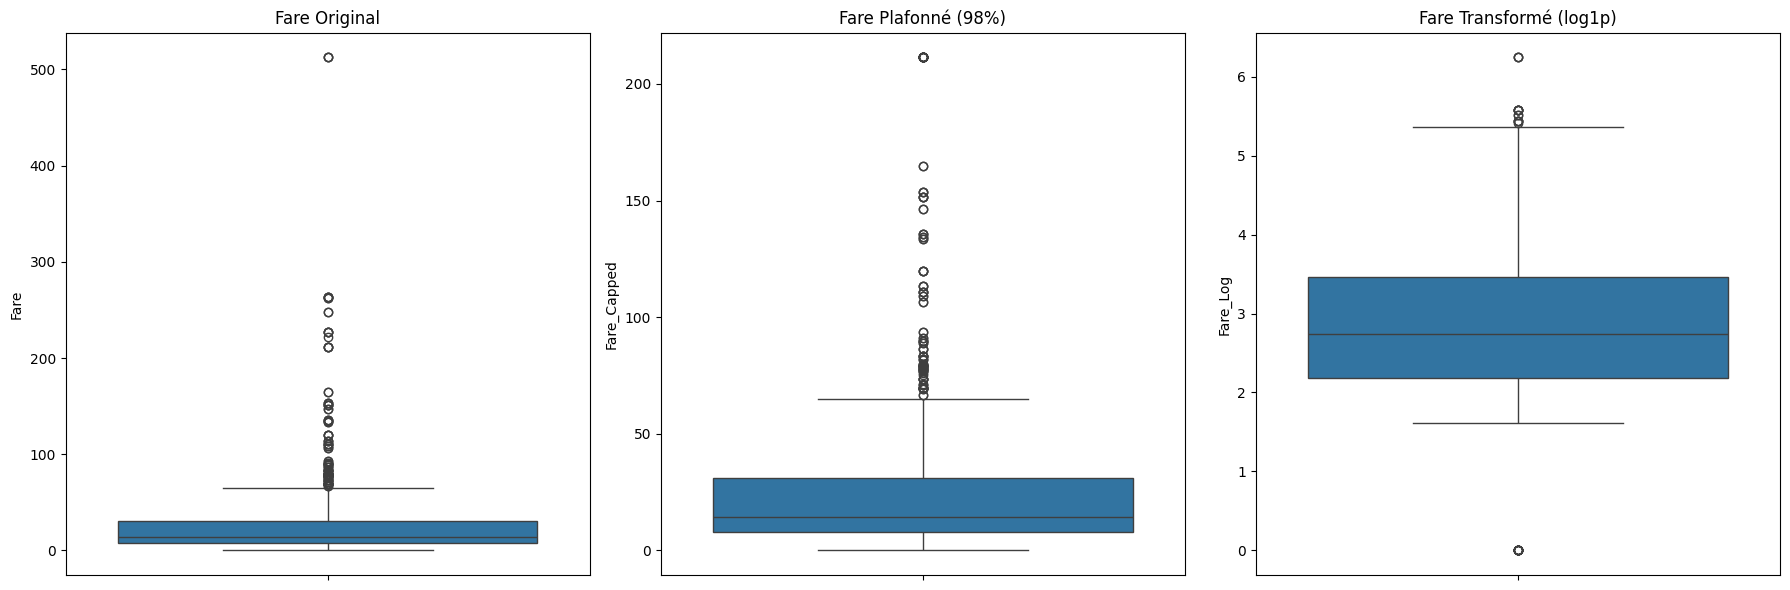

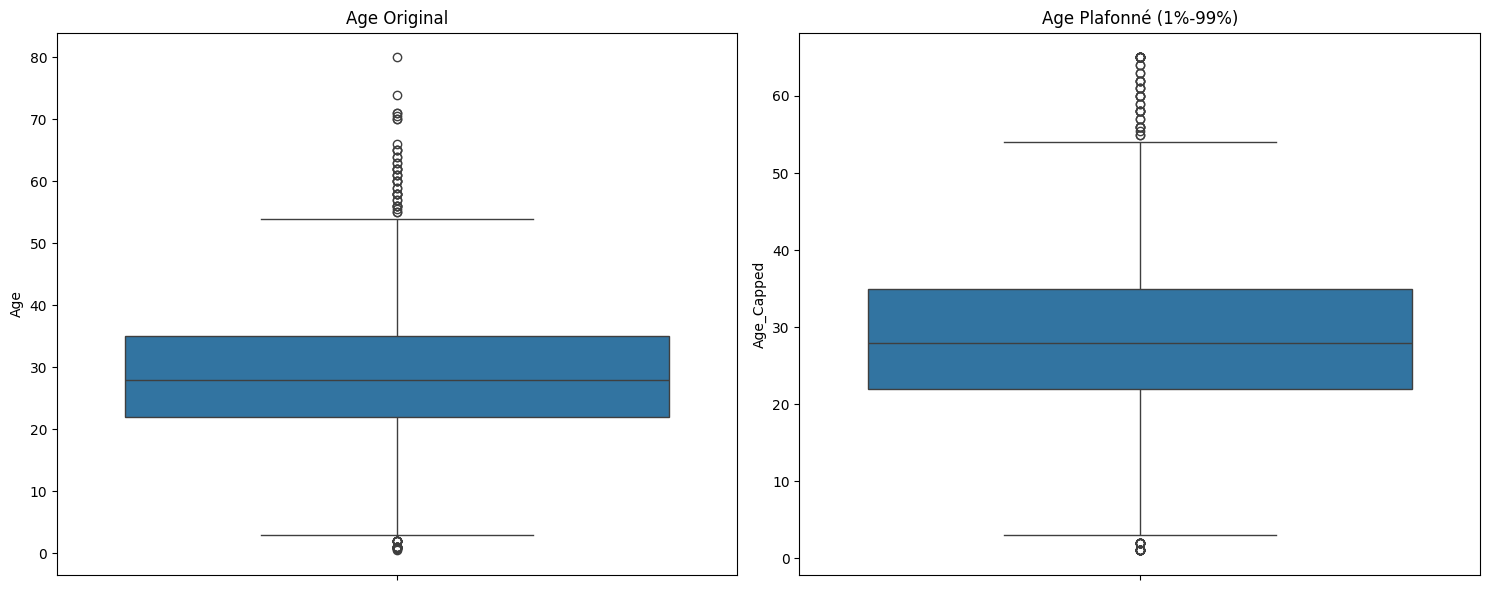

In [ ]:
plt.figure(figsize=(18, 6))

# Fare: Original vs Capped vs Log-transformed
plt.subplot(1, 3, 1)
sns.boxplot(y=df_titanic_cleaned['Fare'])
plt.title('Fare Original')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_titanic_cleaned['Fare_Capped'])
plt.title('Fare Plafonné (98%)')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_titanic_cleaned['Fare_Log'])
plt.title('Fare Transformé (log1p)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))

# Age: Original vs Capped
plt.subplot(1, 2, 1)
sns.boxplot(y=df_titanic_cleaned['Age'])
plt.title('Age Original')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_titanic_cleaned['Age_Capped'])
plt.title('Age Plafonné (1%-99%)')

plt.tight_layout()
plt.show()

🌟 Exercise 5: Data Standardization and Normalization
Goal: Scale numerical features to prepare for modeling.


In [ ]:
numerical_features_to_scale = ['Age_Capped', 'Fare_Log', 'FamilySize', 'Pclass']

print("Fonctionnalités numériques à mettre à l'échelle:", numerical_features_to_scale)

Fonctionnalités numériques à mettre à l'échelle: ['Age_Capped', 'Fare_Log', 'FamilySize', 'Pclass']


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Initialiser les scalers
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# Appliquer StandardScaler à Age_Capped et Fare_Log
df_titanic_cleaned[['Age_Scaled', 'Fare_Scaled']] = scaler_standard.fit_transform(df_titanic_cleaned[['Age_Capped', 'Fare_Log']])

# Appliquer MinMaxScaler à FamilySize et Pclass
df_titanic_cleaned[['FamilySize_Scaled', 'Pclass_Scaled']] = scaler_minmax.fit_transform(df_titanic_cleaned[['FamilySize', 'Pclass']])

print("Aperçu des colonnes mises à l'échelle:")
display(df_titanic_cleaned[['Age_Capped', 'Age_Scaled', 'Fare_Log', 'Fare_Scaled', 'FamilySize', 'FamilySize_Scaled', 'Pclass', 'Pclass_Scaled']].head())

Aperçu des colonnes mises à l'échelle:


,Age_Capped,Age_Scaled,Fare_Log,Fare_Scaled,FamilySize,FamilySize_Scaled,Pclass,Pclass_Scaled
0,22.0,-0.569558,2.110213,-0.879741,2,0.1,3,1.0
1,38.0,0.677983,4.280593,1.361220,2,0.1,1,0.0
2,26.0,-0.257673,2.188856,-0.798540,1,0.0,3,1.0
3,35.0,0.444069,3.990834,1.062038,2,0.1,1,0.0
4,35.0,0.444069,2.202765,-0.784179,1,0.0,3,1.0


### Vérification des distributions après mise à l'échelle


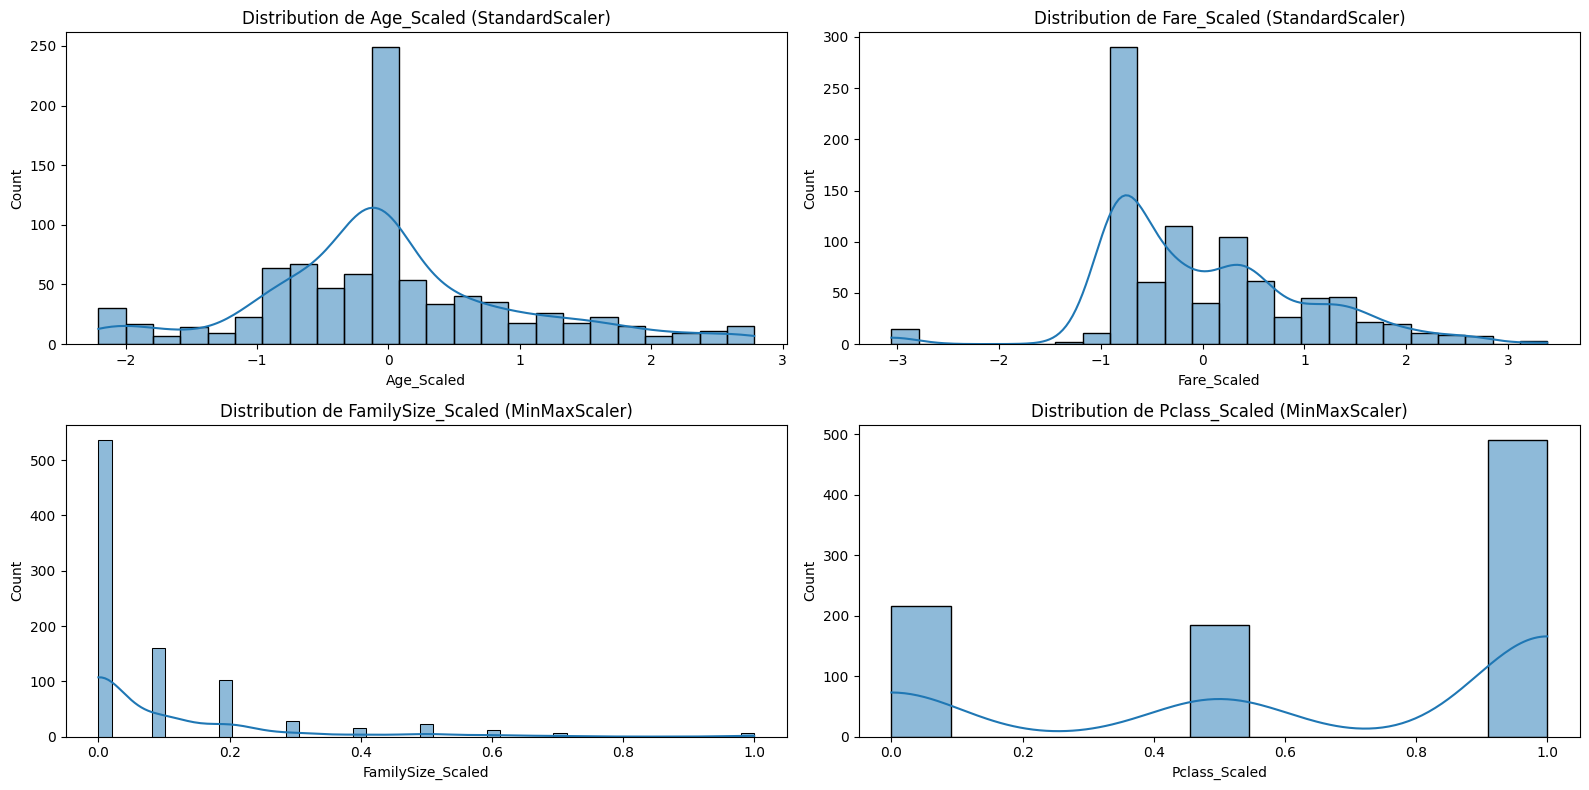

In [ ]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
sns.histplot(df_titanic_cleaned['Age_Scaled'], kde=True)
plt.title('Distribution de Age_Scaled (StandardScaler)')

plt.subplot(2, 2, 2)
sns.histplot(df_titanic_cleaned['Fare_Scaled'], kde=True)
plt.title('Distribution de Fare_Scaled (StandardScaler)')

plt.subplot(2, 2, 3)
sns.histplot(df_titanic_cleaned['FamilySize_Scaled'], kde=True)
plt.title('Distribution de FamilySize_Scaled (MinMaxScaler)')

plt.subplot(2, 2, 4)
sns.histplot(df_titanic_cleaned['Pclass_Scaled'], kde=True)
plt.title('Distribution de Pclass_Scaled (MinMaxScaler)')

plt.tight_layout()
plt.show()

### Récapitulatif de l'exercice 5


Exercise 6: Feature Encoding
Goal: Finalize categorical variable encoding.

### Suppression des colonnes catégorielles originales


In [ ]:
columns_to_drop = ['Sex', 'Embarked', 'Title', 'Name', 'Ticket', 'Cabin', 'Fare']

df_titanic_cleaned = df_titanic_cleaned.drop(columns=columns_to_drop)

print("Aperçu du DataFrame après suppression des colonnes originales:")
display(df_titanic_cleaned.head())
print("Forme du DataFrame après la finalisation de l'encodage des caractéristiques:", df_titanic_cleaned.shape)

Aperçu du DataFrame après suppression des colonnes originales:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,FamilySize,Sex_Encoded,Embarked_Encoded,Title_Master,...,Title_Mr,Title_Mrs,Title_Rare/Other,Fare_Capped,Age_Capped,Fare_Log,Age_Scaled,Fare_Scaled,FamilySize_Scaled,Pclass_Scaled
0,1,0,3,22.0,1,0,2,1,2,0.0,...,1.0,0.0,0.0,7.2500,22.0,2.110213,-0.569558,-0.879741,0.1,1.0
1,2,1,1,38.0,1,0,2,0,0,0.0,...,0.0,1.0,0.0,71.2833,38.0,4.280593,0.677983,1.361220,0.1,0.0
2,3,1,3,26.0,0,0,1,0,2,0.0,...,0.0,0.0,0.0,7.9250,26.0,2.188856,-0.257673,-0.798540,0.0,1.0
3,4,1,1,35.0,1,0,2,0,2,0.0,...,0.0,1.0,0.0,53.1000,35.0,3.990834,0.444069,1.062038,0.1,0.0
4,5,0,3,35.0,0,0,1,1,2,0.0,...,1.0,0.0,0.0,8.0500,35.0,2.202765,0.444069,-0.784179,0.0,1.0


Forme du DataFrame après la finalisation de l'encodage des caractéristiques: (891, 21)


Exercise 7: Data Transformation for Age Feature
Goal: Create and encode age groups.


### Création et encodage des groupes d'âge



In [3]:
import pandas as pd
import numpy as np

# Fallback: If df_titanic_cleaned is not defined, create a minimal version
if 'df_titanic_cleaned' not in locals() and 'df_titanic_cleaned' not in globals():
    print("Attention: 'df_titanic_cleaned' n'est pas défini. Création d'une version simplifiée pour cet exercice.")
    print("Pour une exécution complète et correcte, veuillez exécuter toutes les cellules précédentes du notebook.")

    # Load original data and perform minimal steps to get 'Age_Capped'
    temp_df = pd.read_csv('/content/train.csv')

    # Fill missing Age values (as done in Exercise 2)
    median_age = temp_df['Age'].median()
    temp_df['Age'].fillna(median_age, inplace=True)

    # Cap Age values (as done in Exercise 4)
    age_lower_bound = temp_df['Age'].quantile(0.01)
    age_upper_bound = temp_df['Age'].quantile(0.99)
    temp_df['Age_Capped'] = temp_df['Age'].clip(lower=age_lower_bound, upper=age_upper_bound)

    df_titanic_cleaned = temp_df[['Age_Capped']].copy() # Create a minimal df with just Age_Capped

# Définir les limites des catégories d'âge
bins = [0, 12, 18, 60, df_titanic_cleaned['Age_Capped'].max() + 1] # +1 pour inclure la valeur max
labels = ['Enfant', 'Adolescent', 'Adulte', 'Senior']

# Créer la colonne 'AgeGroup'
df_titanic_cleaned['AgeGroup'] = pd.cut(df_titanic_cleaned['Age_Capped'], bins=bins, labels=labels, right=False)

# Afficher la distribution des groupes d'âge
print("Distribution des groupes d'âge:")
display(df_titanic_cleaned['AgeGroup'].value_counts())

# Appliquer l'encodage one-hot à 'AgeGroup'
age_group_one_hot = pd.get_dummies(df_titanic_cleaned['AgeGroup'], prefix='AgeGroup', dtype=int)

# Concaténer le DataFrame encodé en one-hot au DataFrame principal
# Ensure indices are aligned for concatenation, especially if df_titanic_cleaned was created minimally
df_titanic_cleaned = df_titanic_cleaned.reset_index(drop=True)
age_group_one_hot = age_group_one_hot.reset_index(drop=True)
df_titanic_cleaned = pd.concat([df_titanic_cleaned, age_group_one_hot], axis=1)

print("Aperçu du DataFrame avec les nouvelles colonnes AgeGroup encodées:")
display(df_titanic_cleaned[['Age_Capped', 'AgeGroup', 'AgeGroup_Enfant', 'AgeGroup_Adolescent', 'AgeGroup_Adulte', 'AgeGroup_Senior']].head())

Attention: 'df_titanic_cleaned' n'est pas défini. Création d'une version simplifiée pour cet exercice.
Pour une exécution complète et correcte, veuillez exécuter toutes les cellules précédentes du notebook.
Distribution des groupes d'âge:


/tmp/ipykernel_5465/752999193.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  temp_df['Age'].fillna(median_age, inplace=True)


,count
AgeGroup,
Adulte,752
Enfant,68
Adolescent,45
Senior,26


Aperçu du DataFrame avec les nouvelles colonnes AgeGroup encodées:


,Age_Capped,AgeGroup,AgeGroup_Enfant,AgeGroup_Adolescent,AgeGroup_Adulte,AgeGroup_Senior
0,22.0,Adulte,0,0,1,0
1,38.0,Adulte,0,0,1,0
2,26.0,Adulte,0,0,1,0
3,35.0,Adulte,0,0,1,0
4,35.0,Adulte,0,0,1,0
